<a href="https://colab.research.google.com/github/Laila116/MLregression/blob/main/Regression_Laila17_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Regression Modell in Machine Learning
## Laila Almejbel


## **load the Boston Housing dataset** (via GitHub)

### Download CSV from GitHub

In [ ]:
from google.colab import files

# Lokale Datei hochladen
uploaded = files.upload()

Saving BostonHousing.csv to BostonHousing.csv


In [ ]:
!ls

boston	BostonHousing.csv  sample_data


### Read in CSV file

In [ ]:
import pandas as pd

# CSV-Datei laden
boston_df = pd.read_csv('BostonHousing.csv')
boston_df.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


## **Preperation Data**

### Check Data

In [ ]:
# Informationen zum Datensatz anzeigen (Datentypen, fehlende Werte)
print(boston_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       506 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    int64  
 10  ptratio  506 non-null    float64
 11  b        506 non-null    float64
 12  lstat    506 non-null    float64
 13  medv     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB
None


In [ ]:
# Weitere nützliche Informationen
print(boston_df.describe())

             crim          zn       indus        chas         nox          rm  \
count  506.000000  506.000000  506.000000  506.000000  506.000000  506.000000   
mean     3.613524   11.363636   11.136779    0.069170    0.554695    6.284634   
std      8.601545   23.322453    6.860353    0.253994    0.115878    0.702617   
min      0.006320    0.000000    0.460000    0.000000    0.385000    3.561000   
25%      0.082045    0.000000    5.190000    0.000000    0.449000    5.885500   
50%      0.256510    0.000000    9.690000    0.000000    0.538000    6.208500   
75%      3.677083   12.500000   18.100000    0.000000    0.624000    6.623500   
max     88.976200  100.000000   27.740000    1.000000    0.871000    8.780000   

              age         dis         rad         tax     ptratio           b  \
count  506.000000  506.000000  506.000000  506.000000  506.000000  506.000000   
mean    68.574901    3.795043    9.549407  408.237154   18.455534  356.674032   
std     28.148861    2.1057

### data separation as X and Y

In [ ]:
y = boston_df['medv']
y

,medv
0,24.0
1,21.6
2,34.7
3,33.4
4,36.2
...,...
501,22.4
502,20.6
503,23.9
504,22.0


### Data splitting

In [ ]:
from sklearn.model_selection import train_test_split

# Features (x) und Zielvariable (y)
x = boston_df.drop('medv', axis=1)
y = boston_df['medv']

# Aufteilen in Trainings- und Testdaten (80/20)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Optional: Aufteilen der Trainingsdaten in Training und Validierung (70/15/15 insgesamt)
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.15, random_state=42)

print(f"Trainingsdaten: {x_train.shape}")
print(f"Validierungsdaten: {x_val.shape}")
print(f"Testdaten: {x_test.shape}")


Trainingsdaten: (343, 13)
Validierungsdaten: (61, 13)
Testdaten: (102, 13)


In [ ]:
from sklearn.preprocessing import StandardScaler

# Skalierung der Trainingsdaten
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)

# **Modell Building**

## **linear Regression**

### Training the modle

In [ ]:
# Modelltraining
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(x_train , y_train)

LinearRegression()

### Applaying the modle to make predection

In [ ]:
# Vorhersagen
y_lr_train_pred = lr.predict(x_train)
y_lr_test_pred = lr.predict(x_test)

print (y_lr_train_pred, y_lr_test_pred)

[24.3667864  17.88872915 27.75306166 12.79872884 24.36312068 21.62525042
 24.89795952 20.9835835  27.4457389  23.83629047 20.64993051 33.25444487
 30.01566577 15.8715647  24.71918147 17.64934374 17.94381242 23.87921755
 16.62658328 32.47559079 15.0196127  19.96557722 12.18297655 15.23195008
 27.19179425 36.53279438 28.40977483 21.46014946 23.16433868 16.167942
 45.04705098 31.91698773 12.91126973 25.90615739 22.10839839 22.64889498
 29.50117083 12.54817358  7.73304877 22.60218969 -0.53907371 30.54054436
 15.20657842 31.63593489 20.17788787 15.1538423  19.86262499 23.98887235
 24.12661475 12.95795318 25.58455352 21.38376306 26.70232894 12.69609259
 12.97823535 16.92377101 37.93152976 20.95365263  5.54838849 13.61037083
 23.97965091 27.42109585  8.29292469 26.4665521  28.00547457 18.45435234
 24.67190215 42.32105936 22.46924859 17.19010506 19.64104678 28.13891777
 31.55599121 42.1894311  37.57250308 32.99900672 17.31105695 27.85335091
 31.79625281 25.0958472  30.98367741 21.06150289 18.6

## Evalute model performence

In [ ]:
# Evaluierung
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd

# Berechnung der Metriken für das Lineare Regressionsmodell
lr_train_mse = mean_squared_error(y_train, y_lr_train_pred)
lr_train_r2 = r2_score(y_train, y_lr_train_pred)

lr_test_mse = mean_squared_error(y_test, y_lr_test_pred)
lr_test_r2 = r2_score(y_test, y_lr_test_pred)

# Ergebnisse in einer Tabelle speichern
lr_results = pd.DataFrame({
    'Method': ['Linear Regression'],
    'MSE Train': [lr_train_mse],
    'R² Train': [lr_train_r2],
    'MSE Test': [lr_test_mse],
    'R² Test': [lr_test_r2]
})

lr_results

,Method,MSE Train,R² Train,MSE Test,R² Test
0,Linear Regression,20.71339,0.764695,25.094994,0.657798


## Random Forest

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
import numpy as np


rf = RandomForestRegressor(random_state=42)

rf.fit(x_train, y_train)

param_grid = {
    'n_estimators': [50, 100, 200],  # Anzahl der Bäume
    'max_depth': np.arange(1,20),  # Maximale Tiefe der Bäume
    'min_samples_split': [2, 5, 10],  # Minimale Samples für einen Split
    'min_samples_leaf': [1, 2, 4],  # Minimale Samples pro Blatt
    'max_features': ['sqrt', 'log2']  # Korrigierte Optionen für max_features
}


# Setze GridSearchCV
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=3, n_jobs=-1, verbose=2)

grid_search.fit(x_train, y_train)

print(f"Beste Parameter: {grid_search.best_params_}")
print(f"Bestes Modell: {grid_search.best_estimator_}")


Fitting 3 folds for each of 1026 candidates, totalling 3078 fits
Beste Parameter: {'max_depth': 15, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}
Bestes Modell: RandomForestRegressor(max_depth=15, max_features='sqrt', n_estimators=50,
                      random_state=42)


In [ ]:
# Hole das beste Modell
best_rf = grid_search.best_estimator_

# Trainiere das Modell auf den Trainingsdaten
best_rf.fit(x_train, y_train)


RandomForestRegressor(max_depth=15, max_features='sqrt', n_estimators=50,
                      random_state=42)

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

# Vorhersagen mit dem besten Random Forest-Modell
y_pred_best_rf = best_rf.predict(x_test)

# Berechne MSE und R²
mse_best_rf = mean_squared_error(y_test, y_pred_best_rf)
r2_best_rf = r2_score(y_test, y_pred_best_rf)

# Berechnung der Metriken für das Random Forest-Modell auf den Trainingsdaten
y_pred_best_rf_train = best_rf.predict(x_train)
mse_best_rf_train = mean_squared_error(y_train, y_pred_best_rf_train)
r2_best_rf_train = r2_score(y_train, y_pred_best_rf_train)

rf_results = pd.DataFrame({
    'Method': ['Random Forest'],
    'MSE Train': [mse_best_rf_train],
    'R² Train': [r2_best_rf_train],
    'MSE Test': [mse_best_rf],
    'R² Test': [r2_best_rf]
})

# Ausgabe der Tabelle
print(rf_results)


          Method  MSE Train  R² Train  MSE Test   R² Test
0  Random Forest   2.234789  0.974613  12.07316  0.835367


## Evaluate the Model Performance

In [ ]:
df_model = pd.concat([lr_results, rf_results], axis=0)
df_model.reset_index(drop=True, inplace=True)
df_model

,Method,MSE Train,R² Train,MSE Test,R² Test
0,Linear Regression,20.713390,0.764695,25.094994,0.657798
1,Random Forest,2.234789,0.974613,12.073160,0.835367


# **Data Visualisation with Scatter plots**

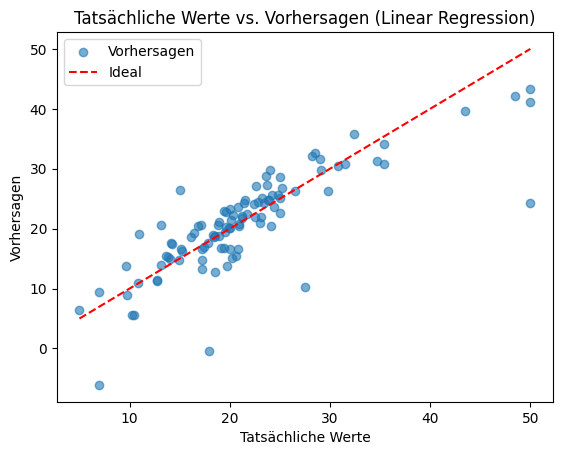

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.scatter(y_test, y_lr_test_pred, label="Vorhersagen", alpha=0.6)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--', label="Ideal")
plt.title("Tatsächliche Werte vs. Vorhersagen (Linear Regression)")
plt.xlabel("Tatsächliche Werte")
plt.ylabel("Vorhersagen")
plt.legend()
plt.show()


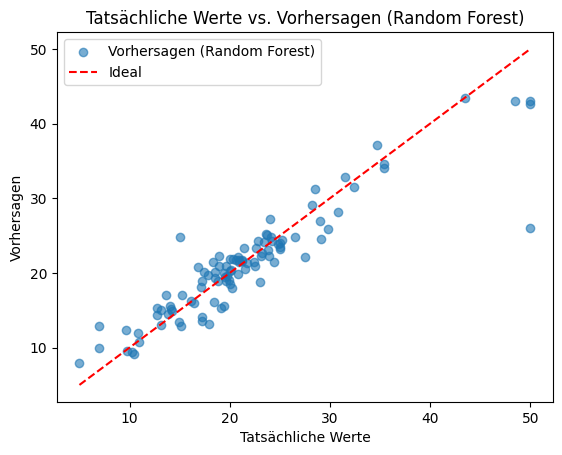

In [ ]:
# Plot für das Random Forest-Modell
plt.scatter(y_test, y_pred_best_rf, label="Vorhersagen (Random Forest)", alpha=0.6)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--', label="Ideal")
plt.title("Tatsächliche Werte vs. Vorhersagen (Random Forest)")
plt.xlabel("Tatsächliche Werte")
plt.ylabel("Vorhersagen")
plt.legend()
plt.show()

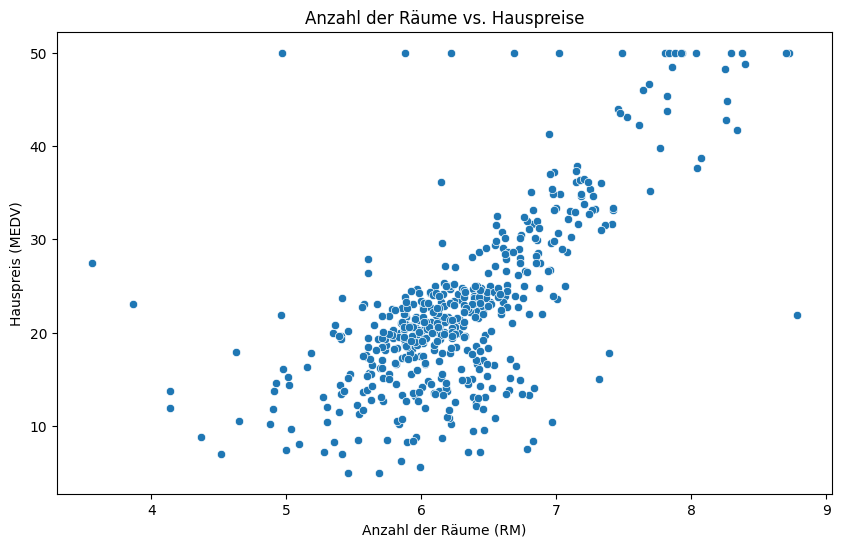

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Scatterplot zwischen feature 'RM' und Y-wert 'MEDV'
plt.figure(figsize=(10, 6))
sns.scatterplot(x=boston_df['rm'], y=boston_df['medv'])
plt.title('Anzahl der Räume vs. Hauspreise')
plt.xlabel('Anzahl der Räume (RM)')
plt.ylabel('Hauspreis (MEDV)')
plt.show()


In [ ]:

print(df_model.columns)

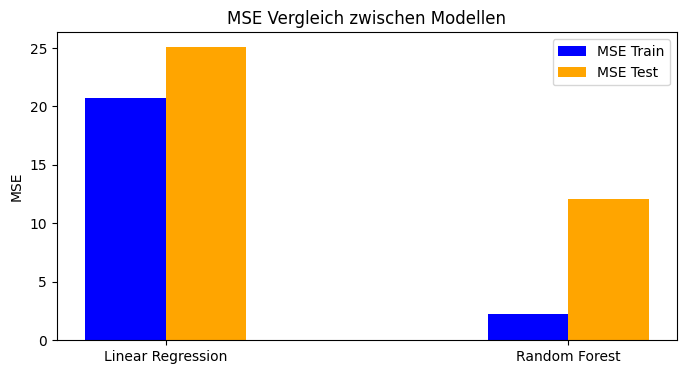

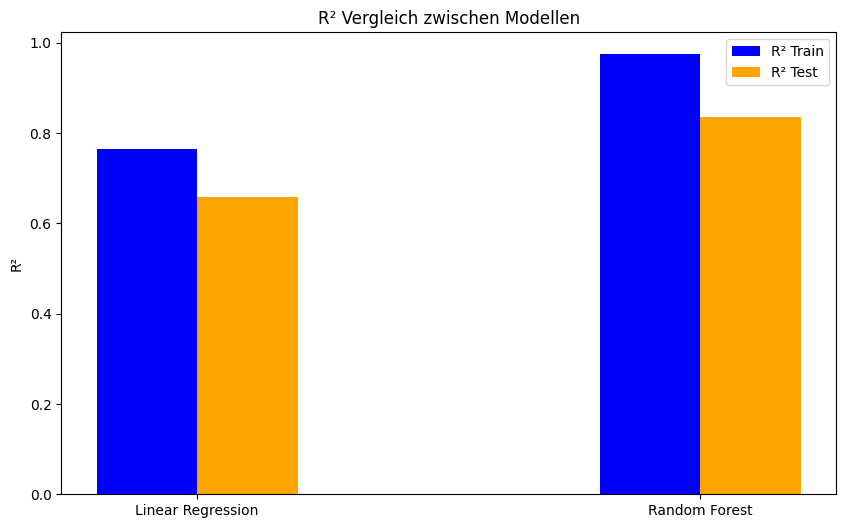

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd


# Balkendiagramm für MSE
plt.figure(figsize=(8, 4))
bar_width = 0.20
x = range(len(df_model['Method']))

plt.bar(x, df_model['MSE Train'], width=bar_width, label='MSE Train', color='blue')
plt.bar([p + bar_width for p in x], df_model['MSE Test'], width=bar_width, label='MSE Test', color='orange')

plt.xticks([p + bar_width / 2 for p in x], df_model['Method'])
plt.ylabel('MSE')
plt.title('MSE Vergleich zwischen Modellen')
plt.legend()
plt.show()

# Balkendiagramm für R²
plt.figure(figsize=(10, 6))
plt.bar(x, df_model['R² Train'], width=bar_width, label='R² Train', color='blue')
plt.bar([p + bar_width for p in x], df_model['R² Test'], width=bar_width, label='R² Test', color='orange')

plt.xticks([p + bar_width / 2 for p in x], df_model['Method'])
plt.ylabel('R²')
plt.title('R² Vergleich zwischen Modellen')
plt.legend()
plt.show()
